# NB03b — Embedding Similarity Calibration

Before scoring gap-fill candidates, we need to understand what cosine similarity
means in ESM-2 embedding space. Key questions:

1. What's the cosine similarity between proteins that catalyze the **same reaction**?
2. What's the similarity between proteins catalyzing **different reactions**?
3. What's the similarity between a candidate and **random genome proteins**?
4. Can cosine similarity discriminate same-reaction from different-reaction pairs?

**Inputs**: `data/candidate_embeddings.json`, `data/all_candidates.parquet`, genome FAISS indexes

**Outputs**: `figures/embedding_calibration.png`, `data/similarity_baselines.csv`

In [1]:
import json
import numpy as np
import faiss
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
import os

DATA_OUT = Path('..') / 'user_data'
FIG_OUT = Path('..') / 'figures'
USER_DATA = Path('..') / 'user_data'
GENOME_DIR = USER_DATA / 'ecoli-files'
FASTA_EXT = '.faa'
FIG_OUT.mkdir(exist_ok=True)

## 1. Load Embeddings and Reaction Assignments

In [2]:
with open(DATA_OUT / 'candidate_embeddings.json') as f:
    emb_data = json.load(f)

emb_map = {e['query_id']: np.array(e['query_embedding'], dtype='float32') for e in emb_data}
for v in emb_map.values():
    v /= np.linalg.norm(v)

candidates = pd.read_parquet(DATA_OUT / 'all_candidates.parquet')

rxn_to_proteins = candidates.groupby('rxn')['uniprot_id'].apply(lambda x: list(set(x))).to_dict()
rxn_to_proteins = {r: [p for p in ps if p in emb_map] for r, ps in rxn_to_proteins.items()}
rxn_to_proteins = {r: ps for r, ps in rxn_to_proteins.items() if len(ps) >= 2}

print(f"Proteins with embeddings: {len(emb_map)}")
print(f"Reactions with >=2 embedded proteins: {len(rxn_to_proteins)}")
print(f"Proteins per reaction (for pairwise):")
for rxn, ps in sorted(rxn_to_proteins.items(), key=lambda x: -len(x[1]))[:10]:
    print(f"  {rxn}: {len(ps)} proteins")

Proteins with embeddings: 3168
Reactions with >=2 embedded proteins: 31
Proteins per reaction (for pairwise):
  rxn12298: 1126 proteins
  rxn04455: 929 proteins
  rxn04660: 369 proteins
  rxn01327: 368 proteins
  rxn12225: 142 proteins
  rxn13647: 140 proteins
  rxn01361: 99 proteins
  rxn02107: 98 proteins
  rxn04658: 96 proteins
  rxn03978: 79 proteins


## 2. Same-Reaction Pairwise Similarity

In [3]:
same_rxn_sims = []
same_rxn_labels = []

for rxn, proteins in rxn_to_proteins.items():
    for p1, p2 in combinations(proteins, 2):
        sim = float(np.dot(emb_map[p1], emb_map[p2]))
        same_rxn_sims.append(sim)
        same_rxn_labels.append(rxn)

same_rxn_sims = np.array(same_rxn_sims)
print(f"Same-reaction pairs: {len(same_rxn_sims)}")
print(f"  Mean:   {same_rxn_sims.mean():.4f}")
print(f"  Median: {np.median(same_rxn_sims):.4f}")
print(f"  Std:    {same_rxn_sims.std():.4f}")
print(f"  Min:    {same_rxn_sims.min():.4f}")
print(f"  Max:    {same_rxn_sims.max():.4f}")
print(f"  5th %%:  {np.percentile(same_rxn_sims, 5):.4f}")
print(f"  95th %%: {np.percentile(same_rxn_sims, 95):.4f}")

Same-reaction pairs: 1255141
  Mean:   0.9208
  Median: 0.9371
  Std:    0.0690
  Min:    0.2758
  Max:    1.0000
  5th %%:  0.8104
  95th %%: 0.9838


## 3. Cross-Reaction Pairwise Similarity (Background)

In [4]:
all_proteins = list(emb_map.keys())
protein_to_rxns = {}
for rxn, ps in rxn_to_proteins.items():
    for p in ps:
        protein_to_rxns.setdefault(p, set()).add(rxn)

rng = np.random.default_rng(42)
n_cross_samples = min(50000, len(same_rxn_sims) * 10)
cross_rxn_sims = []

attempts = 0
while len(cross_rxn_sims) < n_cross_samples and attempts < n_cross_samples * 5:
    i, j = rng.choice(len(all_proteins), 2, replace=False)
    p1, p2 = all_proteins[i], all_proteins[j]
    rxns1 = protein_to_rxns.get(p1, set())
    rxns2 = protein_to_rxns.get(p2, set())
    if not rxns1 & rxns2:
        sim = float(np.dot(emb_map[p1], emb_map[p2]))
        cross_rxn_sims.append(sim)
    attempts += 1

cross_rxn_sims = np.array(cross_rxn_sims)
print(f"Cross-reaction pairs: {len(cross_rxn_sims)}")
print(f"  Mean:   {cross_rxn_sims.mean():.4f}")
print(f"  Median: {np.median(cross_rxn_sims):.4f}")
print(f"  Std:    {cross_rxn_sims.std():.4f}")
print(f"  Min:    {cross_rxn_sims.min():.4f}")
print(f"  Max:    {cross_rxn_sims.max():.4f}")
print(f"  5th %%:  {np.percentile(cross_rxn_sims, 5):.4f}")
print(f"  95th %%: {np.percentile(cross_rxn_sims, 95):.4f}")

Cross-reaction pairs: 50000
  Mean:   0.9084
  Median: 0.9240
  Std:    0.0604
  Min:    0.2868
  Max:    0.9821
  5th %%:  0.8064
  95th %%: 0.9579


## 4. Candidate vs Random Genome Protein Similarity

In [5]:
test_genome = '219790_10_1'
genome_index = faiss.read_index(str(GENOME_DIR / f'{test_genome}-protein{FASTA_EXT}.faiss'))
n_genome = genome_index.ntotal

sample_candidates = rng.choice(all_proteins, min(200, len(all_proteins)), replace=False)

top1_sims = []
top5_mean_sims = []
for pid in sample_candidates:
    vec = emb_map[pid].reshape(1, -1).copy()
    D, I = genome_index.search(vec, 5)
    top1_sims.append(float(D[0][0]))
    top5_mean_sims.append(float(D[0].mean()))

top1_sims = np.array(top1_sims)
top5_mean_sims = np.array(top5_mean_sims)

print(f"Candidate vs genome {test_genome} (n={len(sample_candidates)}):")
print(f"  Top-1 hit — Mean: {top1_sims.mean():.4f}, Median: {np.median(top1_sims):.4f}, Std: {top1_sims.std():.4f}")
print(f"  Top-1 hit — Min: {top1_sims.min():.4f}, Max: {top1_sims.max():.4f}")
print(f"  Top-5 mean — Mean: {top5_mean_sims.mean():.4f}, Median: {np.median(top5_mean_sims):.4f}")

Candidate vs genome 219790_10_1 (n=200):
  Top-1 hit — Mean: 0.9696, Median: 0.9748, Std: 0.0280
  Top-1 hit — Min: 0.8123, Max: 1.0000
  Top-5 mean — Mean: 0.9619, Median: 0.9690


## 5. Per-Reaction Same-Reaction Similarity

In [6]:
per_rxn_stats = []
for rxn, proteins in rxn_to_proteins.items():
    sims = []
    for p1, p2 in combinations(proteins, 2):
        sims.append(float(np.dot(emb_map[p1], emb_map[p2])))
    if sims:
        per_rxn_stats.append({
            'rxn': rxn,
            'n_proteins': len(proteins),
            'n_pairs': len(sims),
            'mean_sim': np.mean(sims),
            'median_sim': np.median(sims),
            'min_sim': np.min(sims),
            'max_sim': np.max(sims),
            'std_sim': np.std(sims)
        })

per_rxn_df = pd.DataFrame(per_rxn_stats).sort_values('mean_sim', ascending=False)
print("Per-reaction intra-similarity:")
display(per_rxn_df.round(4))

Per-reaction intra-similarity:


,rxn,n_proteins,n_pairs,mean_sim,median_sim,min_sim,max_sim,std_sim
18,rxn03978,79,3081,0.9961,0.9958,0.9865,1.0000,0.0029
4,rxn00510,8,28,0.9933,0.9932,0.9874,0.9986,0.0029
11,rxn01663,4,6,0.9933,0.9936,0.9887,0.9968,0.0032
0,rxn00084,6,15,0.9919,0.9930,0.9806,0.9997,0.0071
2,rxn00141,13,78,0.9882,0.9914,0.9682,0.9999,0.0090
6,rxn00577,4,6,0.9881,0.9902,0.9785,0.9973,0.0062
17,rxn03883,3,3,0.9876,0.9855,0.9846,0.9926,0.0036
26,rxn05902,12,66,0.9869,0.9856,0.9754,1.0000,0.0083
7,rxn00738,54,1431,0.9842,0.9958,0.8966,1.0000,0.0251
9,rxn01361,99,4851,0.9822,0.9866,0.9268,1.0000,0.0137


## 6. Visualization

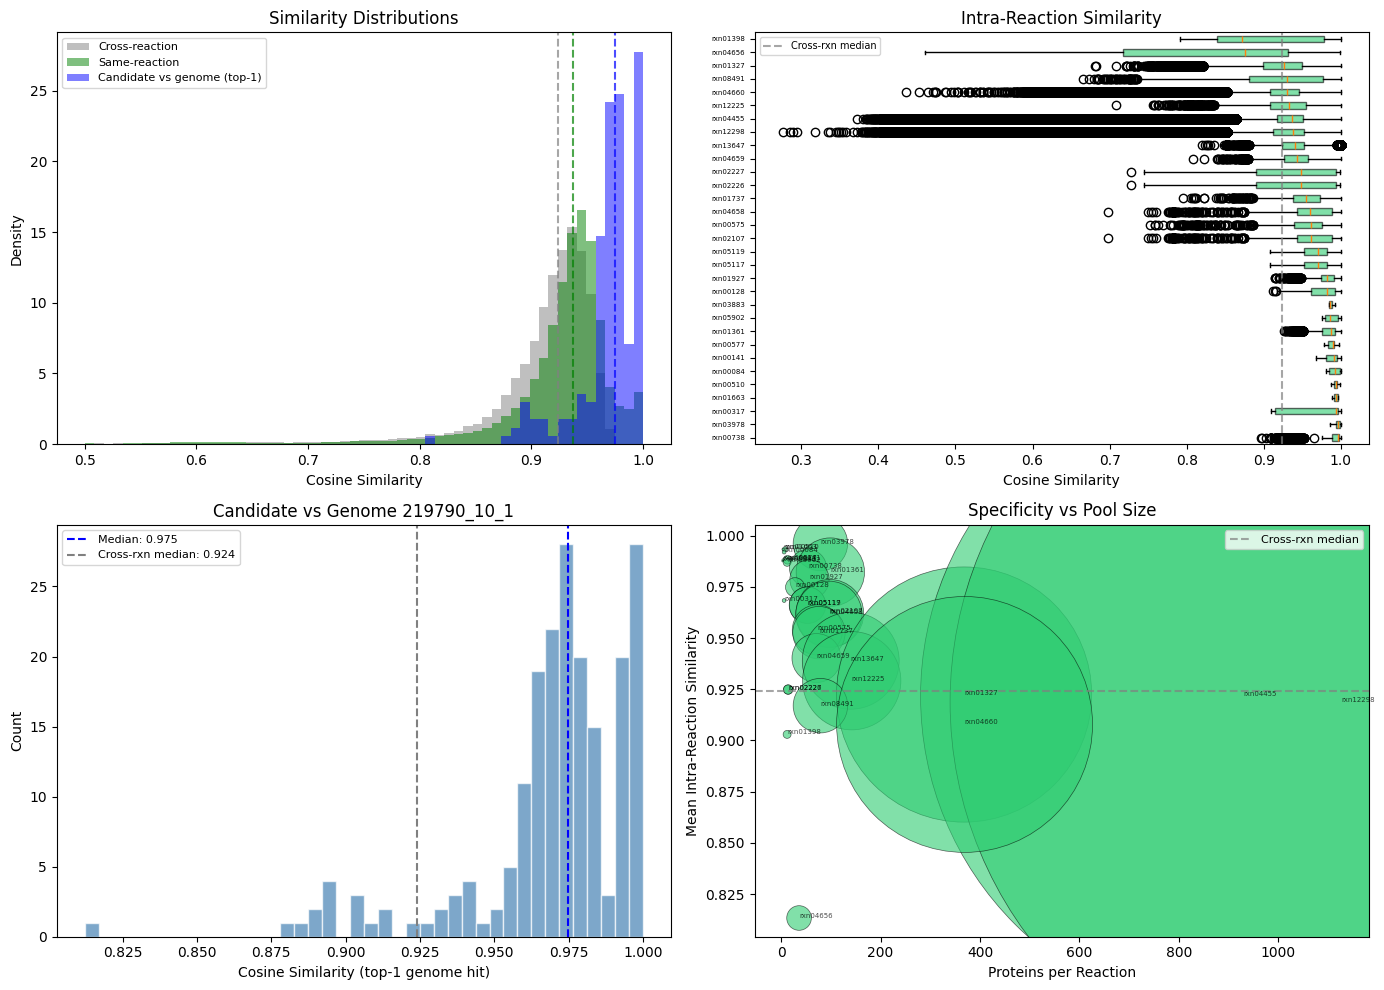

Saved to ../figures/embedding_calibration.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Overlapping histograms
bins = np.linspace(0.5, 1.0, 60)
axes[0, 0].hist(cross_rxn_sims, bins=bins, alpha=0.5, density=True, label='Cross-reaction', color='gray')
axes[0, 0].hist(same_rxn_sims, bins=bins, alpha=0.5, density=True, label='Same-reaction', color='green')
axes[0, 0].hist(top1_sims, bins=bins, alpha=0.5, density=True, label='Candidate vs genome (top-1)', color='blue')
axes[0, 0].axvline(np.median(cross_rxn_sims), color='gray', linestyle='--', alpha=0.7)
axes[0, 0].axvline(np.median(same_rxn_sims), color='green', linestyle='--', alpha=0.7)
axes[0, 0].axvline(np.median(top1_sims), color='blue', linestyle='--', alpha=0.7)
axes[0, 0].set_xlabel('Cosine Similarity')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Similarity Distributions')
axes[0, 0].legend(fontsize=8)

# Panel 2: Per-reaction box plot
rxn_order = per_rxn_df.sort_values('median_sim', ascending=False)['rxn'].tolist()
box_data = []
box_labels = []
for rxn in rxn_order:
    proteins = rxn_to_proteins[rxn]
    sims = [float(np.dot(emb_map[p1], emb_map[p2])) for p1, p2 in combinations(proteins, 2)]
    if sims:
        box_data.append(sims)
        box_labels.append(rxn)

bp = axes[0, 1].boxplot(box_data, vert=False, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#2ecc71')
    patch.set_alpha(0.6)
axes[0, 1].set_yticklabels(box_labels, fontsize=5)
axes[0, 1].axvline(np.median(cross_rxn_sims), color='gray', linestyle='--', alpha=0.7, label='Cross-rxn median')
axes[0, 1].set_xlabel('Cosine Similarity')
axes[0, 1].set_title('Intra-Reaction Similarity')
axes[0, 1].legend(fontsize=7)

# Panel 3: Candidate vs genome top-1 distribution
axes[1, 0].hist(top1_sims, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[1, 0].axvline(np.median(top1_sims), color='blue', linestyle='--', label=f'Median: {np.median(top1_sims):.3f}')
axes[1, 0].axvline(np.median(cross_rxn_sims), color='gray', linestyle='--', label=f'Cross-rxn median: {np.median(cross_rxn_sims):.3f}')
axes[1, 0].set_xlabel('Cosine Similarity (top-1 genome hit)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title(f'Candidate vs Genome {test_genome}')
axes[1, 0].legend(fontsize=8)

# Panel 4: n_proteins vs mean similarity
axes[1, 1].scatter(per_rxn_df['n_proteins'], per_rxn_df['mean_sim'], 
                    s=per_rxn_df['n_pairs']*0.5, alpha=0.6, color='#2ecc71', edgecolors='black', linewidths=0.5)
for _, row in per_rxn_df.iterrows():
    axes[1, 1].annotate(row['rxn'], (row['n_proteins'], row['mean_sim']), fontsize=5, alpha=0.7)
axes[1, 1].axhline(np.median(cross_rxn_sims), color='gray', linestyle='--', alpha=0.7, label='Cross-rxn median')
axes[1, 1].set_xlabel('Proteins per Reaction')
axes[1, 1].set_ylabel('Mean Intra-Reaction Similarity')
axes[1, 1].set_title('Specificity vs Pool Size')
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_OUT / 'embedding_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {FIG_OUT / 'embedding_calibration.png'}")

## 7. Summary and Thresholds

In [8]:
baselines = pd.DataFrame({
    'distribution': ['same_reaction', 'cross_reaction', 'candidate_vs_genome_top1'],
    'n_pairs': [len(same_rxn_sims), len(cross_rxn_sims), len(top1_sims)],
    'mean': [same_rxn_sims.mean(), cross_rxn_sims.mean(), top1_sims.mean()],
    'median': [np.median(same_rxn_sims), np.median(cross_rxn_sims), np.median(top1_sims)],
    'std': [same_rxn_sims.std(), cross_rxn_sims.std(), top1_sims.std()],
    'p5': [np.percentile(same_rxn_sims, 5), np.percentile(cross_rxn_sims, 5), np.percentile(top1_sims, 5)],
    'p95': [np.percentile(same_rxn_sims, 95), np.percentile(cross_rxn_sims, 95), np.percentile(top1_sims, 95)]
})

print("Baseline Similarity Statistics:")
display(baselines.round(4))

baselines.to_csv(DATA_OUT / 'similarity_baselines.csv', index=False)
per_rxn_df.to_csv(DATA_OUT / 'per_reaction_similarity.csv', index=False)
print(f"\nSaved to data/similarity_baselines.csv and data/per_reaction_similarity.csv")

sep = np.median(same_rxn_sims) - np.median(cross_rxn_sims)
print(f"\nSeparation (same-rxn median - cross-rxn median): {sep:.4f}")
if sep > 0.05:
    print("Cosine similarity shows meaningful separation between same-reaction and cross-reaction pairs.")
    print("Embedding-based scoring should add discriminative value.")
else:
    print("WARNING: Minimal separation — ESM-2 embeddings may not discriminate reaction-level function well.")
    print("Consider using rank-based scoring rather than absolute thresholds.")

Baseline Similarity Statistics:


,distribution,n_pairs,mean,median,std,p5,p95
0,same_reaction,1255141,0.9208,0.9371,0.0690,0.8104,0.9838
1,cross_reaction,50000,0.9084,0.9240,0.0604,0.8064,0.9579
2,candidate_vs_genome_top1,200,0.9696,0.9748,0.0280,0.9044,0.9999



Saved to data/similarity_baselines.csv and data/per_reaction_similarity.csv

Separation (same-rxn median - cross-rxn median): 0.0131
Consider using rank-based scoring rather than absolute thresholds.
